<a href="https://colab.research.google.com/github/Alberto2804/Proyecto_ModelosIA/blob/main/datos_costes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- MÉTRICAS DEL MODELO DE REGRESIÓN (COSTES MÉDICOS) ---
R² (Coeficiente de Determinación): 0.8651
MAE (Error Absoluto Medio): 2550.08


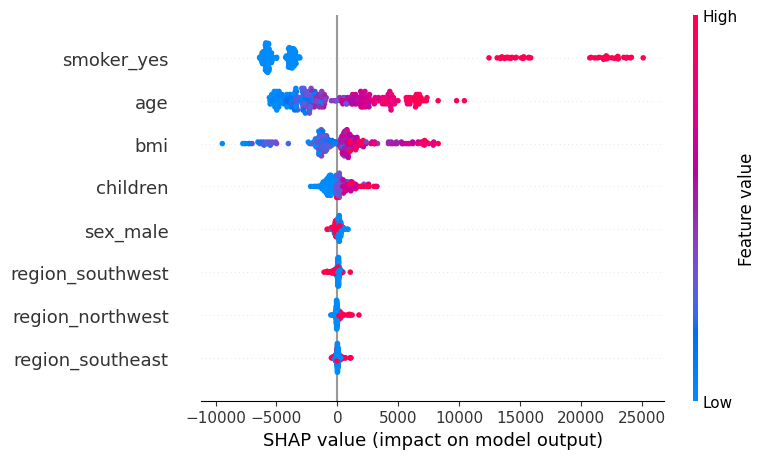

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import shap

df_costes = pd.read_csv('datos_costes.csv')
df_numerico = pd.get_dummies(df_costes, drop_first=True)

X = df_numerico.drop('charges', axis=1)
y = df_numerico['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_regresion = RandomForestRegressor(random_state=42)
modelo_regresion.fit(X_train, y_train)

y_pred = modelo_regresion.predict(X_test)

print("--- MÉTRICAS DEL MODELO DE REGRESIÓN (COSTES MÉDICOS) ---")
print(f"R² (Coeficiente de Determinación): {r2_score(y_test, y_pred):.4f}")
print(f"MAE (Error Absoluto Medio): {mean_absolute_error(y_test, y_pred):.2f}")

explainer = shap.TreeExplainer(modelo_regresion)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)